In [60]:
test = '6П14П-ЕР'

In [61]:
!copy %cd%\..\Ebay\Server\Controllers\Contracts\Ebay.yaml %cd%
!rmdir %cd%\openapi_client\ /s /q
!docker run --rm -v %cd%:/local openapitools/openapi-generator-cli:v7.3.0 generate -i /local/Ebay.yaml -g python-pydantic-v1 -o /local/client --additional-properties=generateSourceCodeOnly=true
!move %cd%/client/openapi_client %cd%/openapi_client
!rmdir %cd%\client\ /s /q

        1 file(s) copied.
[main] INFO  o.o.codegen.DefaultGenerator - Generating with dryRun=false
[main] INFO  o.o.c.ignore.CodegenIgnoreProcessor - Output directory (/local/client) does not exist, or is inaccessible. No file (.openapi-generator-ignore) will be evaluated.
[main] INFO  o.o.codegen.DefaultGenerator - OpenAPI Generator: python-pydantic-v1 (client)
[main] INFO  o.o.codegen.DefaultGenerator - Generator 'python-pydantic-v1' is considered stable.
[main] INFO  o.o.c.l.AbstractPythonPydanticV1Codegen - Environment variable PYTHON_POST_PROCESS_FILE not defined so the Python code may not be properly formatted. To define it, try 'export PYTHON_POST_PROCESS_FILE="/usr/local/bin/yapf -i"' (Linux/Mac)
[main] INFO  o.o.c.l.AbstractPythonPydanticV1Codegen - NOTE: To enable file post-processing, 'enablePostProcessFile' must be set to `true` (--enable-post-process-file for CLI).
[main] INFO  o.o.c.l.PythonPydanticV1ClientCodegen - Environment variable PYTHON_POST_PROCESS_FILE not define

In [62]:
from openapi_client import CategoryValue, LotInfoShort, ProductWithId, ApiClient, Configuration
from openapi_client.api import DefaultApi
import requests
import pandas as pd
from typing import List
import matplotlib.pyplot as plt
from datetime import datetime
from termcolor import colored
from IPython.display import display
import seaborn as sns

In [63]:
server = "naks42.ru"
port = 17443
clientId = "Ebay.Python"
secret = "ac4ab670-ae20-451a-ab4a-3a20275e807d"

In [64]:
unknown_price_discount = 1 - 0.2
ebay_fee = 0.1325
ebay_fee_const = 0.3
payoneer_fee = 0.05 #todo уточнить

In [65]:
def calc_statistics(df_local: pd.DataFrame):
    df_without_changed_names = df_local[df_local.purchase_var_date > df_local.lot_title_change_date]
    
    mean = df_local.purchase_profit.sum() / df_local.total_pcs_per_purchase.sum()
    print('Среднее: ', mean)

    mean_without_changed_names = df_without_changed_names.purchase_profit.sum() / df_without_changed_names.total_pcs_per_purchase.sum()
    print('Среднее (только последние редакции): ', mean_without_changed_names)

    error = abs(mean - mean_without_changed_names) / mean
    
    if error > 0.01:
        print(colored("Среднее и Среднее (только последние редакции) отличается на " + str(error * 100) + "%"))
    
    sns.histplot(data=df_local, x='purchase_profit_per_pcs', weights=df_local.total_pcs_per_purchase, bins=10)
    plt.axvline(x = mean, color = 'b')
    plt.title(product.name + ' Распределение цены для new')
    plt.show()
    
    sns.scatterplot(data=df_local, x="purchase_profit_per_pcs", y="total_pcs_per_purchase", hue="lot_category_test_state")
    plt.axvline(x = mean, color = 'b')
    plt.show()

################################################## 6П14П-ЕР ##################################################
Продано штук:  196 

Распределение по состоянию (проданных штук): 
new    196 

new
Среднее:  15.843433516581134
Среднее (только последние редакции):  15.697308447916086


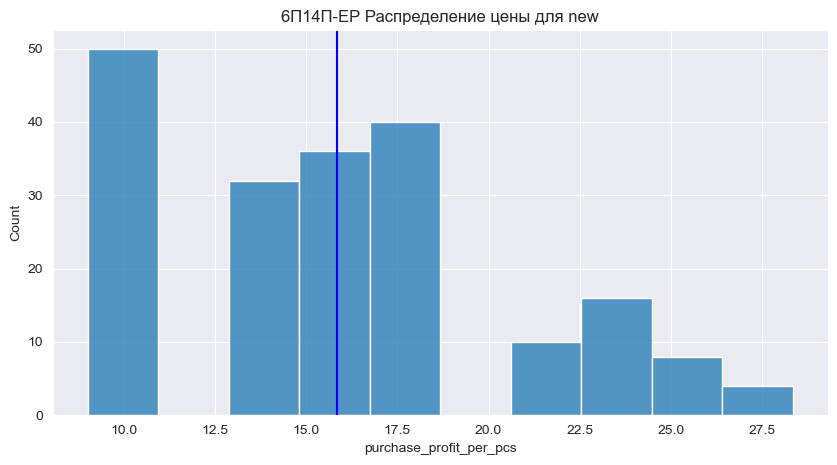

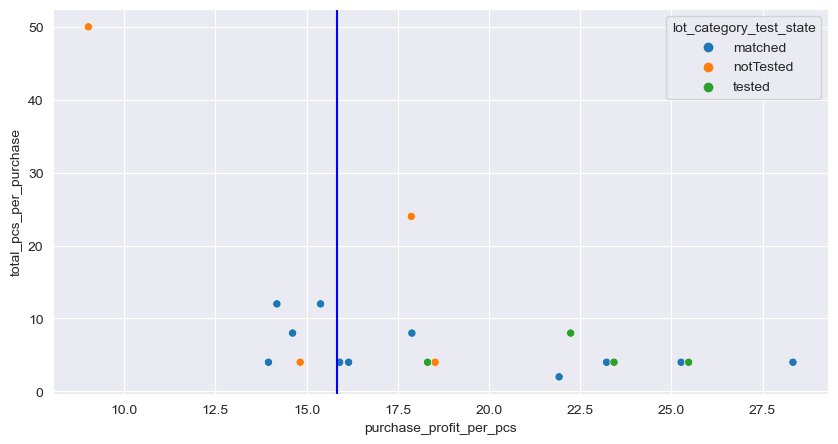

In [66]:
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
plt.rcParams["figure.figsize"] = (10,5)

def get_access_token(url, client_id, client_secret):
    response = requests.post(
        url,
        data={"grant_type": "client_credentials"},
        auth=(client_id, client_secret),
    )
    return response.json()["access_token"]

token = get_access_token(f"https://{server}:{port}/connect/token", clientId, secret)

client = ApiClient(
    configuration=Configuration(host=f'https://{server}:{port}/api/ebay/v1'), header_name='Authorization',
    header_value='Bearer ' + token)

api = DefaultApi(client)

currencies = api.get_currencies()
currency_rates = {}
for currency in currencies:
    if (datetime.now() - datetime.strptime(currencies[0].last_update, '%Y-%m-%dT%H:%M:%S.%fZ')).days > 1:
        raise Exception("exchange rate isn't accurate " + currency.ebay_name)
    currency_rates[currency.ebay_name] = currency.rate

productRowsExcluded = {'search_queries'}
lotRowsExcluded = {'seller', 'located_in', 'purchase_history', 'categories'}
purchaseExcluded = {}

products: List[ProductWithId] = api.get_all_products()


for product in products:
    if product.name != test: continue
    
    print(colored('#' * 50 + f' {product.name} ' + '#' * 50, "red"))
    
    lots: List[LotInfoShort] = api.get_lots(product_id=product.id)

    productRow = {}
    for key, value in product.__dict__.items():
        if key not in productRowsExcluded:
            productRow[f'product_{key}'] = value

    dataFrameArray = []
    for lot in lots:
        lotRow = productRow.copy()
        for key, value in lot.__dict__.items():
            if key not in lotRowsExcluded:
                lotRow[f'lot_{key}'] = value
        
        for category in lot.categories:
            lotRow[f'lot_category_{category.type}'] = category.value
        
        for purchase in lot.purchase_history:
            purchaseRow = lotRow.copy()
            for key, value in purchase.__dict__.items():
                if key not in purchaseExcluded:
                    purchaseRow[f'purchase_{key}'] = value
            dataFrameArray.append(purchaseRow)
    
    if len(dataFrameArray) == 0:
        print("Нет продаж для лота", '\n')
        continue
    
    df = pd.DataFrame(dataFrameArray)

    df.lot_title_change_date = pd.to_datetime(df.lot_title_change_date)
    df.purchase_var_date = pd.to_datetime(df.purchase_var_date)
    df['purchase_price_filled_nulls'] = df.purchase_price.fillna(df.lot_price * unknown_price_discount)
    df['exchange_rate'] = df.lot_currency.map(currency_rates)
    
    df['purchase_total_price'] = df.purchase_price_filled_nulls * df.purchase_quantity + df.lot_shipping + (df.lot_shipping_additional * (df.purchase_quantity - 1))
    df['purchase_total_price_usd'] = df.purchase_total_price / df.exchange_rate
    df['purchase_profit'] = df.purchase_total_price_usd - df.purchase_total_price_usd * ebay_fee - df.purchase_total_price_usd * payoneer_fee - ebay_fee_const
    df['total_pcs_per_purchase'] = df.lot_pcs * df.purchase_quantity
    df['purchase_profit_per_pcs'] = df.purchase_profit / df.total_pcs_per_purchase
     
    print ('Продано штук: ', (df.purchase_quantity * df.lot_pcs).sum(), '\n')
    
    print('Распределение по состоянию (проданных штук): ')
    print(df.groupby('lot_category_condition')['total_pcs_per_purchase'].sum().to_string(header=False), "\n")

    df_new = df[df.lot_category_condition == 'new']
    df_used = df[df.lot_category_condition == 'used']

    if df_new.shape[0] > 0:
        print('new')
        calc_statistics(df_new)
        
    if df_used.shape[0] > 0:
        print('used')
        calc_statistics(df_used)
    print()

In [59]:
df.sort_values(by = 'purchase_profit_per_pcs')

,product_id,product_name,product_last_check_time,lot_lot_id,lot_name,lot_pcs,lot_shipping_country,lot_currency,lot_price,lot_shipping,lot_shipping_additional,lot_condition,lot_condition_description,lot_title_change_date,lot_category_condition,lot_category_test_state,purchase_price,purchase_quantity,purchase_var_date,purchase_price_filled_nulls,exchange_rate,purchase_total_price,purchase_total_price_usd,purchase_profit,total_pcs_per_purchase,purchase_profit_per_pcs
4,4df97794-746d-4d18-9d86-6d027a900ed9,6П14П-ЕР,2024-02-02T11:35:01.888Z,195890033298,50pcs x 6P14P-ER / 7189 / 6BQ5 / EL84 Tubes NOS,50,Germany,US $,690.00,0.0,0.0,New,None,1970-01-01 00:00:00+00:00,new,notTested,NaN,1,2024-02-21 13:38:28+00:00,552.000,1.000000,552.000,552.000000,450.960000,50,9.019200
2,4df97794-746d-4d18-9d86-6d027a900ed9,6П14П-ЕР,2024-02-02T11:35:01.888Z,195292244339,Matched quad 6P14P-ER / 7189 / 6BQ5 / EL84 Tubes Strong NIB,4,Germany,US $,67.06,15.0,5.0,New,None,2024-01-20 11:17:58+00:00,new,matched,NaN,1,2024-01-21 16:02:18+00:00,53.648,1.000000,68.648,68.648000,55.819740,4,13.954935
11,4df97794-746d-4d18-9d86-6d027a900ed9,6П14П-ЕР,2024-02-02T11:35:01.888Z,225012498508,6p14p-er long life tubes NOS Matched quad Gold grid EL84 6BQ5 7189 N709 6p14p-ev,4,Germany,US $,79.00,15.0,2.0,--,NOS,2022-12-28 18:45:28+00:00,new,matched,NaN,3,2022-08-17 22:44:29+00:00,63.200,1.000000,208.600,208.600000,170.230500,12,14.185875
5,4df97794-746d-4d18-9d86-6d027a900ed9,6П14П-ЕР,2024-02-02T11:35:01.888Z,225012498508,6p14p-er long life tubes NOS Matched quad Gold grid EL84 6BQ5 7189 N709 6p14p-ev,4,Germany,US $,79.00,15.0,2.0,--,NOS,2022-12-28 18:45:28+00:00,new,matched,NaN,2,2023-11-12 14:54:34+00:00,63.200,1.000000,143.400,143.400000,116.929500,8,14.616188
10,4df97794-746d-4d18-9d86-6d027a900ed9,6П14П-ЕР,2024-02-02T11:35:01.888Z,225012498508,6p14p-er long life tubes NOS Matched quad Gold grid EL84 6BQ5 7189 N709 6p14p-ev,4,Germany,US $,79.00,15.0,2.0,--,NOS,2022-12-28 18:45:28+00:00,new,matched,NaN,2,2023-02-19 06:45:50+00:00,63.200,1.000000,143.400,143.400000,116.929500,8,14.616188
24,4df97794-746d-4d18-9d86-6d027a900ed9,6П14П-ЕР,2024-02-02T11:35:01.888Z,395067638357,1pc 6P14P-ER/EL84/6BQ5 Soviet Valves Tubes New Same Year And Batch Matched,1,United Kingdom,GBP,18.00,0.0,0.0,New,None,1970-01-01 00:00:00+00:00,new,notTested,NaN,4,2024-02-15 17:05:15+00:00,14.400,0.790077,57.600,72.904287,59.299254,4,14.824814
3,4df97794-746d-4d18-9d86-6d027a900ed9,6П14П-ЕР,2024-02-02T11:35:01.888Z,195292244339,Matched quad 6P14P-ER / 7189 / 6BQ5 / EL84 Tubes Strong NIB,4,Germany,US $,67.06,15.0,5.0,New,None,2024-01-20 11:17:58+00:00,new,matched,67.06,3,2023-12-23 02:46:35+00:00,67.060,1.000000,226.180,226.180000,184.602150,12,15.383513
6,4df97794-746d-4d18-9d86-6d027a900ed9,6П14П-ЕР,2024-02-02T11:35:01.888Z,225012498508,6p14p-er long life tubes NOS Matched quad Gold grid EL84 6BQ5 7189 N709 6p14p-ev,4,Germany,US $,79.00,15.0,2.0,--,NOS,2022-12-28 18:45:28+00:00,new,matched,NaN,1,2023-09-27 17:25:39+00:00,63.200,1.000000,78.200,78.200000,63.628500,4,15.907125
7,4df97794-746d-4d18-9d86-6d027a900ed9,6П14П-ЕР,2024-02-02T11:35:01.888Z,225012498508,6p14p-er long life tubes NOS Matched quad Gold grid EL84 6BQ5 7189 N709 6p14p-ev,4,Germany,US $,79.00,15.0,2.0,--,NOS,2022-12-28 18:45:28+00:00,new,matched,NaN,1,2023-06-10 02:02:25+00:00,63.200,1.000000,78.200,78.200000,63.628500,4,15.907125
8,4df97794-746d-4d18-9d86-6d027a900ed9,6П14П-ЕР,2024-02-02T11:35:01.888Z,225012498508,6p14p-er long life tubes NOS Matched quad Gold grid EL84 6BQ5 7189 N709 6p14p-ev,4,Germany,US $,79.00,15.0,2.0,--,NOS,2022-12-28 18:45:28+00:00,new,matched,NaN,1,2023-06-09 10:42:01+00:00,63.200,1.000000,78.200,78.200000,63.628500,4,15.907125
